# Time-Series Clustering Example

This notebook demonstrates how to cluster time-series using:

1. **Feature-based / vector-based clustering** with `KMeans`
2. **Shape-based time-series clustering** with `TimeSeriesKMeans` and **DTW**

The examples use synthetic time-series so the true clusters are known and easy to visualize.


## 1. Installation

The first part uses only common Python packages.  
The DTW-based clustering section uses `tslearn`.

Run this cell if `tslearn` is not installed.


In [1]:
# Uncomment if needed:
# !pip install tslearn

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

np.random.seed(42)


## 3. Create Synthetic Time-Series Data

We create three groups of time-series:

1. **Cluster 0:** slow sine waves  
2. **Cluster 1:** faster sine waves  
3. **Cluster 2:** upward trend with seasonality  

Each row represents one complete time-series.


In [3]:
n_per_cluster = 30
series_length = 100
time = np.arange(series_length)

all_series = []
true_labels = []

# Cluster 0: slow sine waves
for _ in range(n_per_cluster):
    phase = np.random.uniform(-0.5, 0.5)
    noise = np.random.normal(0, 0.15, series_length)
    y = np.sin((time + phase) / 10) + noise
    all_series.append(y)
    true_labels.append(0)

# Cluster 1: faster sine waves
for _ in range(n_per_cluster):
    phase = np.random.uniform(-0.5, 0.5)
    noise = np.random.normal(0, 0.15, series_length)
    y = np.sin((time + phase) / 4) + noise
    all_series.append(y)
    true_labels.append(1)

# Cluster 2: trend + seasonality
for _ in range(n_per_cluster):
    noise = np.random.normal(0, 0.15, series_length)
    trend = 0.025 * time
    seasonal = 0.4 * np.sin(time / 8)
    y = trend + seasonal + noise
    all_series.append(y)
    true_labels.append(2)

X = np.array(all_series)
true_labels = np.array(true_labels)

print("Dataset shape:", X.shape)
print("Number of time-series:", X.shape[0])
print("Length of each time-series:", X.shape[1])


Dataset shape: (90, 100)
Number of time-series: 90
Length of each time-series: 100


## 4. Visualize the Time-Series

Each plot shows several examples from one true cluster.


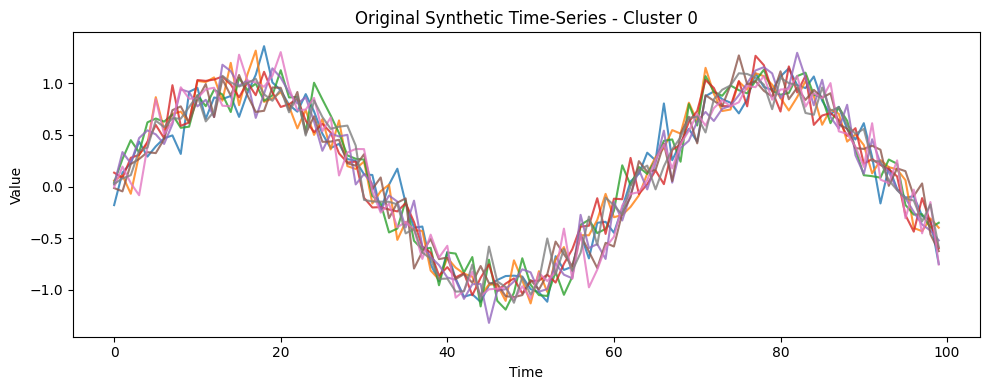

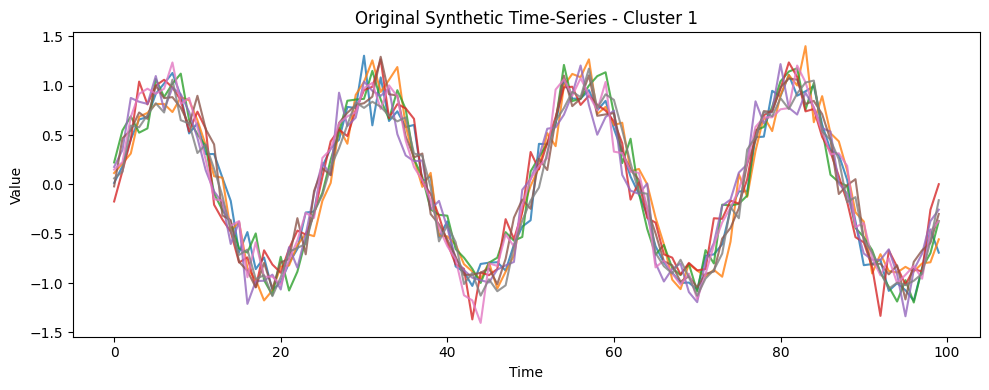

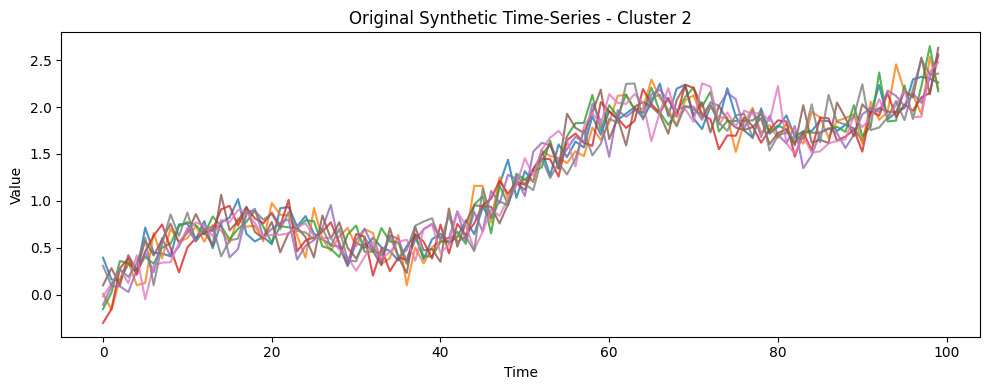

In [4]:
def plot_examples_by_cluster(X, labels, title):
    unique_labels = np.unique(labels)

    for label in unique_labels:
        plt.figure(figsize=(10, 4))
        idx = np.where(labels == label)[0][:8]

        for i in idx:
            plt.plot(X[i], alpha=0.8)

        plt.title(f"{title} - Cluster {label}")
        plt.xlabel("Time")
        plt.ylabel("Value")
        plt.tight_layout()
        plt.show()


plot_examples_by_cluster(X, true_labels, "Original Synthetic Time-Series")


## 5. Normalize Each Time-Series

For time-series clustering, normalization is often important.

Here we apply **z-normalization per time-series**:

\[
z_t = \frac{x_t - \mu}{\sigma}
\]

This makes the clustering focus more on **shape** and less on absolute scale.


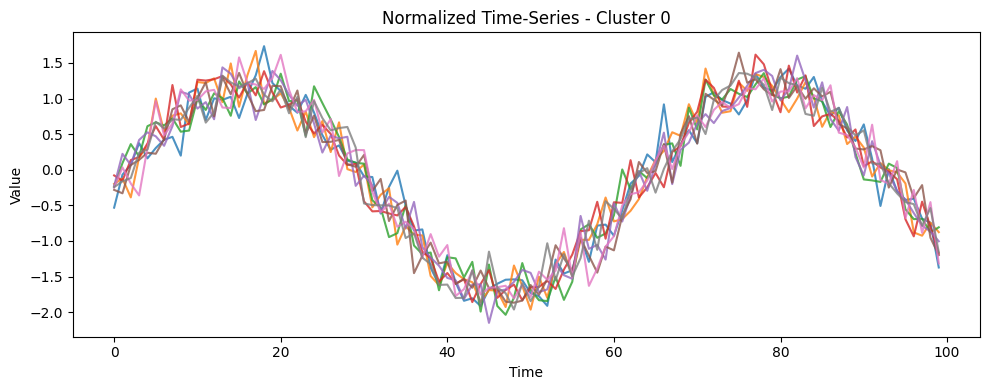

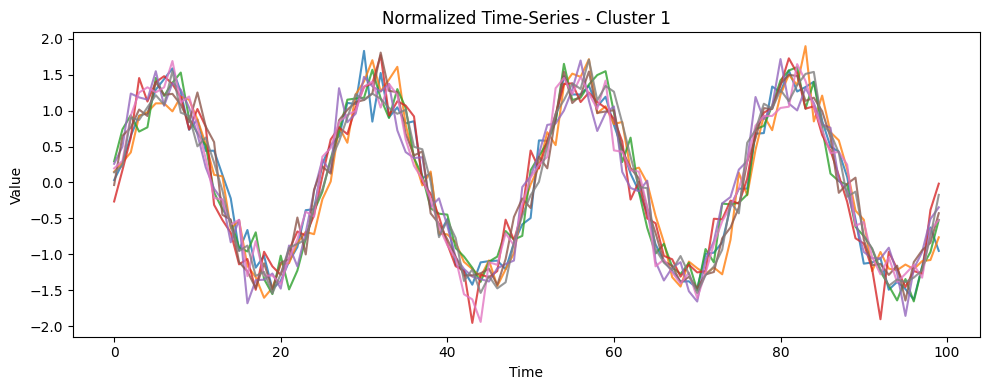

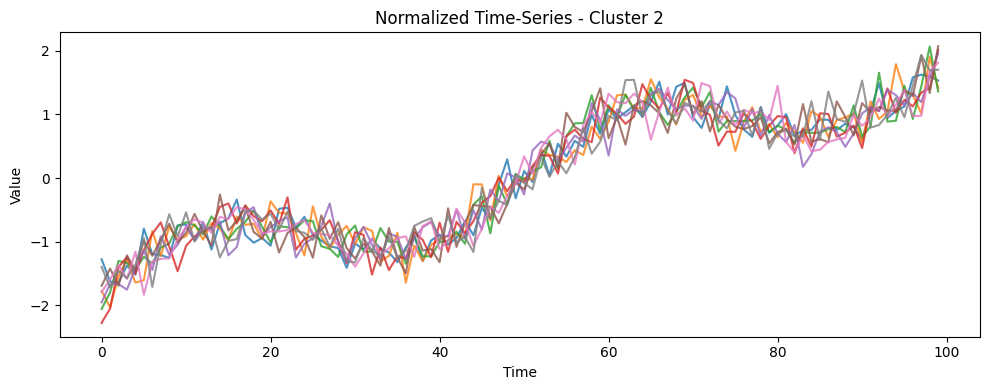

In [5]:
def z_normalize_each_series(X):
    means = X.mean(axis=1, keepdims=True)
    stds = X.std(axis=1, keepdims=True)
    return (X - means) / stds


X_norm = z_normalize_each_series(X)

plot_examples_by_cluster(X_norm, true_labels, "Normalized Time-Series")


# Part A: KMeans on Raw Time-Series Vectors

In this approach, each full time-series is treated as one vector:

\[
x_i = [x_{i,1}, x_{i,2}, ..., x_{i,T}]
\]

Then standard `KMeans` is applied.


In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X_norm)

ari = adjusted_rand_score(true_labels, kmeans_labels)
sil = silhouette_score(X_norm, kmeans_labels)

print("Adjusted Rand Index:", round(ari, 3))
print("Silhouette Score:", round(sil, 3))


Adjusted Rand Index: 1.0
Silhouette Score: 0.773


## 6. Plot KMeans Clusters

The black line represents the cluster centroid.


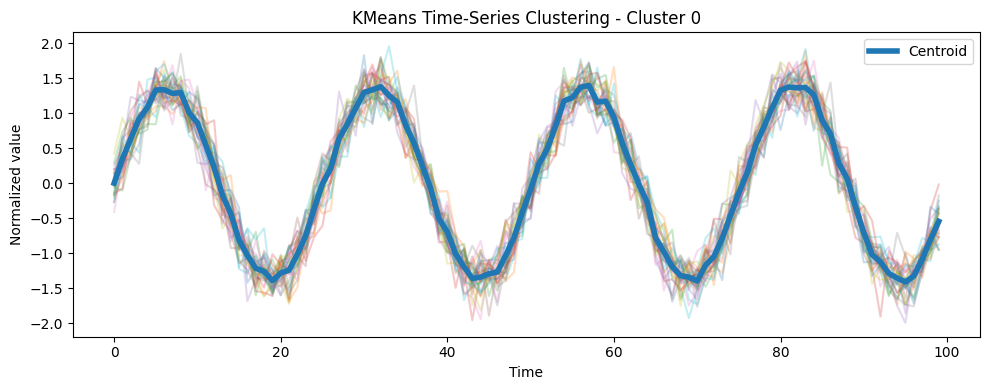

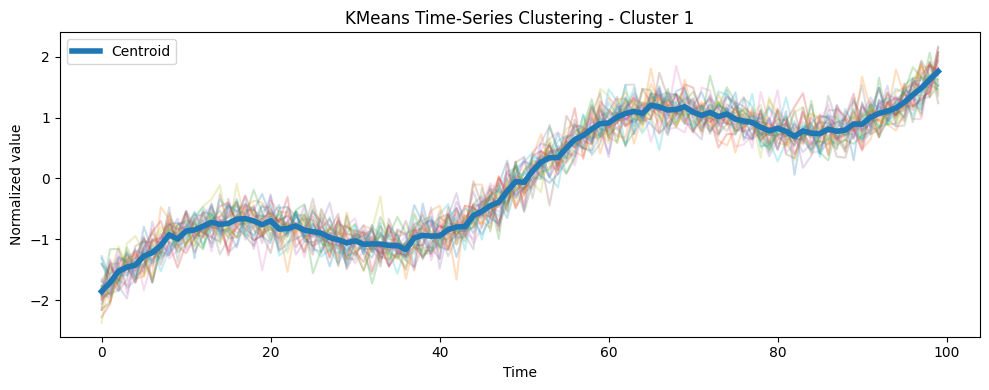

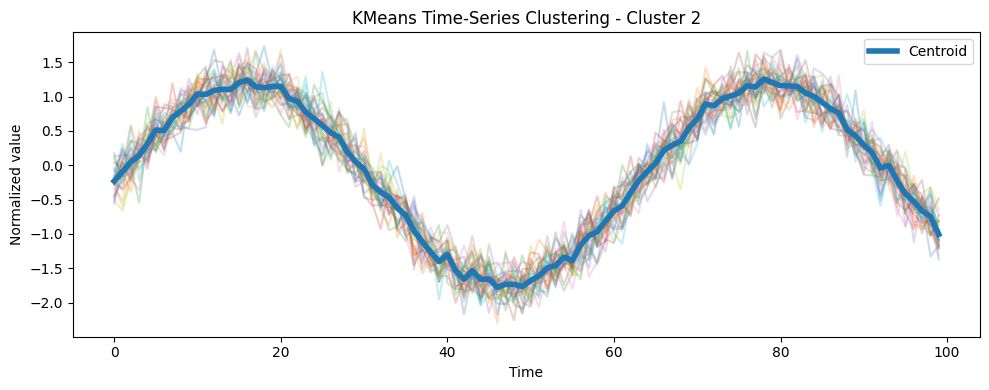

In [7]:
def plot_clusters_with_centroids(X, cluster_labels, centroids=None, title="Clusters"):
    unique_labels = np.unique(cluster_labels)

    for label in unique_labels:
        plt.figure(figsize=(10, 4))
        idx = np.where(cluster_labels == label)[0]

        for i in idx:
            plt.plot(X[i], alpha=0.25)

        if centroids is not None:
            plt.plot(centroids[label], linewidth=4, label="Centroid")

        plt.title(f"{title} - Cluster {label}")
        plt.xlabel("Time")
        plt.ylabel("Normalized value")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_clusters_with_centroids(
    X_norm,
    kmeans_labels,
    centroids=kmeans.cluster_centers_,
    title="KMeans Time-Series Clustering"
)


## 7. PCA Visualization of KMeans Clusters

Since each time-series has 100 dimensions, we use PCA to visualize them in 2D.


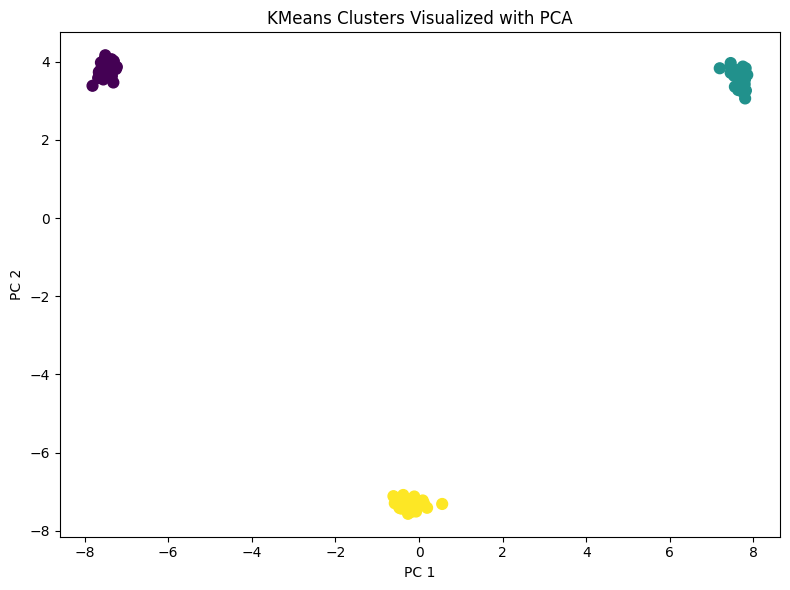

In [8]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_norm)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, s=60)
plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()


# Part B: Time-Series KMeans with DTW

Standard KMeans uses Euclidean distance.  
For time-series, this can be too strict because it compares points at exactly the same time index.

**Dynamic Time Warping (DTW)** allows small temporal shifts and aligns similar shapes.

This is useful when two series have similar patterns but are slightly shifted in time.


In [16]:
!pip install tslearn

try:
    from tslearn.clustering import TimeSeriesKMeans
    from tslearn.utils import to_time_series_dataset
    tslearn_available = True
except ModuleNotFoundError:
    tslearn_available = False
    print("tslearn is not installed. Run: !pip install tslearn")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [17]:
if tslearn_available:
    X_tslearn = to_time_series_dataset(X_norm)

    dtw_kmeans = TimeSeriesKMeans(
        n_clusters=3,
        metric="dtw",
        max_iter=10,
        random_state=42
    )

    dtw_labels = dtw_kmeans.fit_predict(X_tslearn)

    ari_dtw = adjusted_rand_score(true_labels, dtw_labels)

    print("DTW TimeSeriesKMeans Adjusted Rand Index:", round(ari_dtw, 3))
else:
    print("Skipping DTW clustering because tslearn is not installed.")


DTW TimeSeriesKMeans Adjusted Rand Index: 1.0


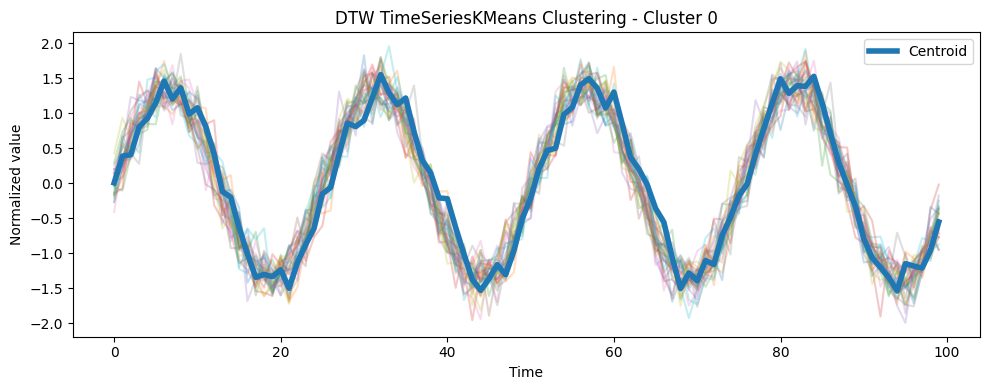

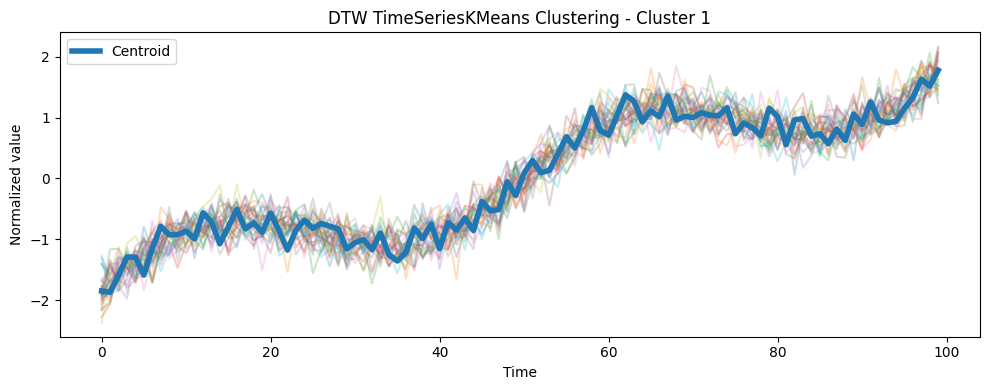

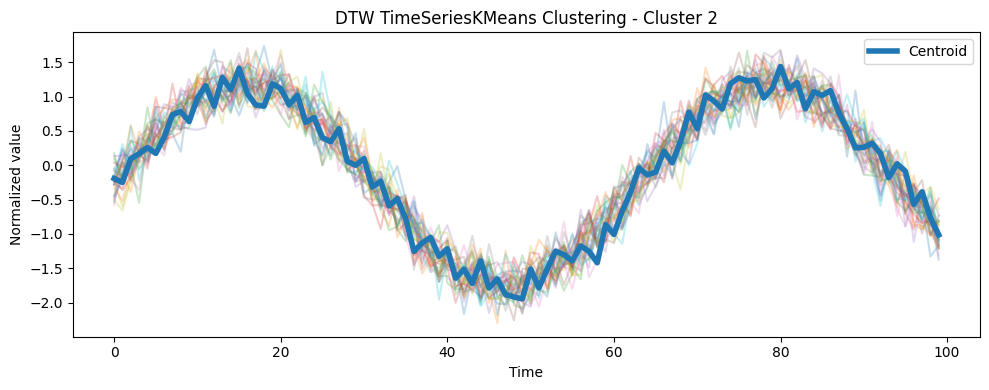

In [18]:
if tslearn_available:
    dtw_centroids = dtw_kmeans.cluster_centers_.squeeze()

    plot_clusters_with_centroids(
        X_norm,
        dtw_labels,
        centroids=dtw_centroids,
        title="DTW TimeSeriesKMeans Clustering"
    )
else:
    print("No plot created because tslearn is not installed.")


# Part C: Feature-Based Time-Series Clustering

Another common approach is to extract summary features from each time-series and cluster those features.

Examples of simple features:

- Mean
- Standard deviation
- Minimum
- Maximum
- Slope
- Autocorrelation
- Energy


In [19]:
def extract_simple_features(X):
    rows = []

    for series in X:
        slope = np.polyfit(np.arange(len(series)), series, deg=1)[0]
        autocorr_1 = pd.Series(series).autocorr(lag=1)
        energy = np.sum(series ** 2)

        rows.append({
            "mean": np.mean(series),
            "std": np.std(series),
            "min": np.min(series),
            "max": np.max(series),
            "slope": slope,
            "autocorr_1": autocorr_1,
            "energy": energy
        })

    return pd.DataFrame(rows)


features = extract_simple_features(X_norm)
features.head()


,mean,std,min,max,slope,autocorr_1,energy
0,9.103829e-17,1.0,-1.913327,1.734919,-0.001276,0.949638,100.0
1,-4.884981e-17,1.0,-1.963651,1.668082,-0.002085,0.945662,100.0
2,1.665335e-17,1.0,-2.036433,1.355984,-0.002236,0.949758,100.0
3,1.332268e-17,1.0,-1.857983,1.616002,-0.002465,0.954139,100.0
4,-3.996803e-17,1.0,-2.150086,1.602502,-0.002713,0.948551,100.0


In [20]:
feature_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

feature_labels = feature_kmeans.fit_predict(features)

ari_features = adjusted_rand_score(true_labels, feature_labels)
sil_features = silhouette_score(features, feature_labels)

print("Feature-based KMeans Adjusted Rand Index:", round(ari_features, 3))
print("Feature-based KMeans Silhouette Score:", round(sil_features, 3))


Feature-based KMeans Adjusted Rand Index: 0.439
Feature-based KMeans Silhouette Score: 0.418


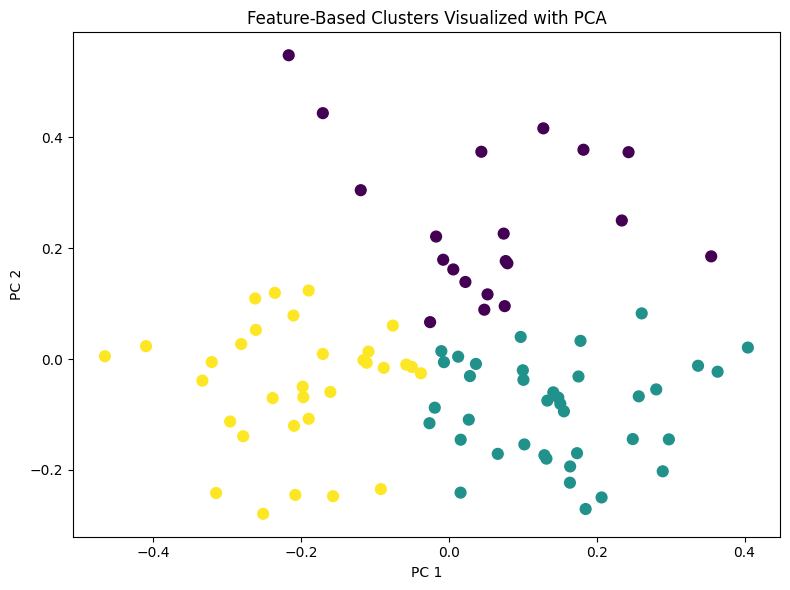

In [21]:
pca_features = PCA(n_components=2, random_state=42)
features_2d = pca_features.fit_transform(features)

plt.figure(figsize=(8, 6))
plt.scatter(features_2d[:, 0], features_2d[:, 1], c=feature_labels, s=60)
plt.title("Feature-Based Clusters Visualized with PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()


# 8. Summary

| Method | Main idea | When to use |
|---|---|---|
| KMeans on raw series | Treat each series as a vector | Aligned time-series |
| TimeSeriesKMeans with DTW | Compare series using temporal alignment | Similar shapes with time shifts |
| Feature-based clustering | Cluster extracted summary features | Large or noisy datasets |

Key idea:

> In time-series clustering, the definition of **similarity** is the most important modeling choice.
